## Designing an AND Gate Perceptron using tensors

This notebook demonstrates how to build a single-neuron Perceptron to model the logical `AND` function. The architecture is derived from computational models inspired by biological neurons, utilizing inputs, weights, a bias, and an activation function.

The `AND` gate takes two binary inputs ($x_1$ and $x_2$) and outputs `1` only if both inputs are `1`. Otherwise, it outputs `0`.

![Agent Node](AND_Gate_Perceptron.png)
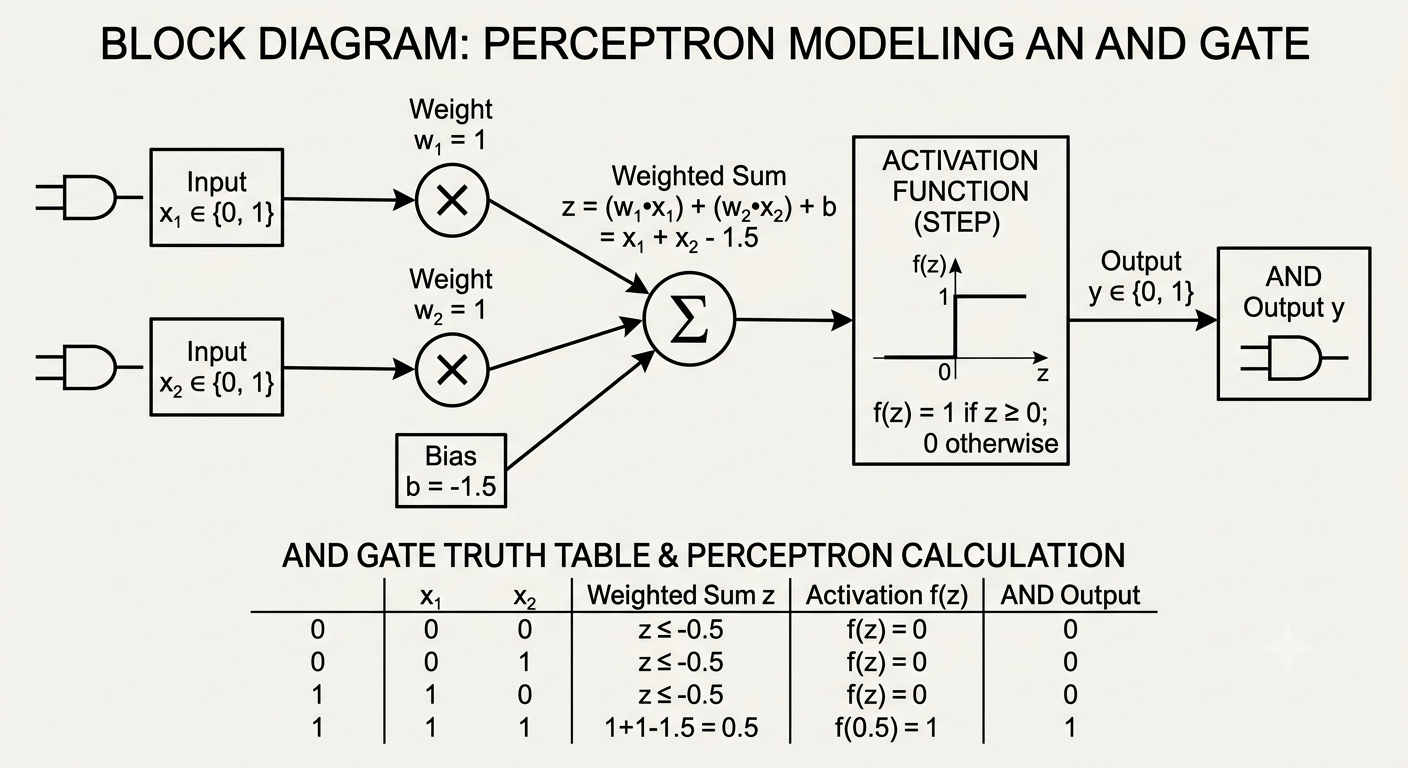

In [1]:
import pandas as pd
import torch.nn as nn
import torch
import torch.nn.functional as F
import numpy as np

In [5]:
# Input matrix
X_data = np.matrix(
    [
        # x1, x2
        [0, 0, 0, 1, 1, 0, 1, 1]
    ]
).reshape((4,2))
display(X_data)

# Expected
Y_data = np.array([0, 0, 0, 1]).reshape((4, 1))
display(Y_data)

matrix([[0, 0],
        [0, 1],
        [1, 0],
        [1, 1]])

array([[0],
       [0],
       [0],
       [1]])

In [6]:
X = torch.tensor(X_data, requires_grad=False, dtype=torch.float32)
Y = torch.tensor(Y_data, requires_grad=False, dtype=torch.float32)

#### Initialize Weights and Biases with gradients

In [45]:
W = torch.randn(2,1, requires_grad=True, dtype=torch.float32)
B = torch.randn(1, requires_grad=True, dtype=torch.float32)
display(W)
display(B)


tensor([[-0.8987],
        [-0.1126]], requires_grad=True)

tensor([-0.2320], requires_grad=True)

#### Precition and the Loss Functions

In [46]:
# Predicted (Sigmoid activation)
Y_hat = F.sigmoid(X @ W + B)
display(Y_hat)

# MSE
Loss = ((Y - Y_hat)**2).mean()
display(Loss)

tensor([[0.4423],
        [0.4147],
        [0.2440],
        [0.2239]], grad_fn=<SigmoidBackward0>)

tensor(0.2574, grad_fn=<MeanBackward0>)

#### Now, begin the Steepest Grad Descent
SGD to calculate the W and B with minimized Loss.

In [47]:
epochs = 10000
LR = 0.01

for epoch in range(epochs):
    # Predict
    Y_hat = F.sigmoid(X @ W + B)
    #display(Y_hat)

    # MSE
    Loss = ((Y - Y_hat)**2).mean()
    #display(Loss)

    # Backpropagate the gradients all the way up to W and B
    Loss.backward(retain_graph=True)

    with torch.no_grad():
        W -= W.grad * LR
        B -= B.grad * LR

    if epoch % 10 == 0:
        print(">> [Bw-pr] W_grad: ", W.grad)
        print(">> [Bw-pr] B_grad: ", B.grad)
        print(">> [Bw-pr] LOSS: ", Loss)

    # CLear the grads
    W.grad.zero_()
    B.grad.zero_()

>> [Bw-pr] W_grad:  tensor([[-0.0449],
        [-0.0171]])
>> [Bw-pr] B_grad:  tensor([0.0600])
>> [Bw-pr] LOSS:  tensor(0.2574, grad_fn=<MeanBackward0>)
>> [Bw-pr] W_grad:  tensor([[-0.0450],
        [-0.0173]])
>> [Bw-pr] B_grad:  tensor([0.0595])
>> [Bw-pr] LOSS:  tensor(0.2568, grad_fn=<MeanBackward0>)
>> [Bw-pr] W_grad:  tensor([[-0.0450],
        [-0.0174]])
>> [Bw-pr] B_grad:  tensor([0.0591])
>> [Bw-pr] LOSS:  tensor(0.2562, grad_fn=<MeanBackward0>)
>> [Bw-pr] W_grad:  tensor([[-0.0451],
        [-0.0176]])
>> [Bw-pr] B_grad:  tensor([0.0587])
>> [Bw-pr] LOSS:  tensor(0.2556, grad_fn=<MeanBackward0>)
>> [Bw-pr] W_grad:  tensor([[-0.0451],
        [-0.0178]])
>> [Bw-pr] B_grad:  tensor([0.0583])
>> [Bw-pr] LOSS:  tensor(0.2551, grad_fn=<MeanBackward0>)
>> [Bw-pr] W_grad:  tensor([[-0.0452],
        [-0.0179]])
>> [Bw-pr] B_grad:  tensor([0.0578])
>> [Bw-pr] LOSS:  tensor(0.2545, grad_fn=<MeanBackward0>)
>> [Bw-pr] W_grad:  tensor([[-0.0452],
        [-0.0181]])
>> [Bw-pr] B_grad

In [48]:
Loss.detach()
W.detach()
B.detach()
print(f"Loss (MSE) = {Loss.item():4.2}")

print(f"\n--- AND Function --- \nW={W}; \n\nB={B}")

Loss (MSE) = 0.063

--- AND Function --- 
W=tensor([[1.7214],
        [1.7455]], requires_grad=True); 

B=tensor([-2.7637], requires_grad=True)


#### Predicted values

In [44]:
print(np.matrix(F.sigmoid(X @ W + B).data))

[[0.08242147]
 [0.08105583]
 [0.08105739]
 [0.91894716]]
